# Load libraries

In [2]:
import os
import pandas as pd
import squidpy as sq
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from spatialdata_io import xenium
from scimilarity.utils import lognorm_counts, align_dataset
from scimilarity import CellAnnotation
import glob

/opt/homebrew/Caskroom/miniconda/base/envs/scimilarity/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [3]:
sdata = xenium("../../data/kidney/20241025__200743__BWH_20241025_SHRUTI_RACHEL/output-XETG00392__0045655__BS21-N65682A2__20241025__201009/")
adata = sdata.tables["table"]
adata.layers["counts"] = adata.X.copy()
adata_scimilarity = adata.copy()
# sdata = xenium("../../data/kidney/20240803__182820__BWH_20240803_skin_Shruti_kidney/output-XETG00150__0018462__BS22_12012A1__20240803__183643/")
# adata = sdata.tables["table"]

INFO     reading                                                                                                   
         ../../data/kidney/20241025__200743__BWH_20241025_SHRUTI_RACHEL/output-XETG00392__0045655__BS21-N65682A2__2
         0241025__201009/cell_feature_matrix.h5                                                                    


/var/folders/2_/vr6ztx9d0yx6xy6kxndy39rc0000gn/T/ipykernel_2324/4228128859.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = xenium("../../data/kidney/20241025__200743__BWH_20241025_SHRUTI_RACHEL/output-XETG00392__0045655__BS21-N65682A2__20241025__201009/")
/opt/homebrew/Caskroom/miniconda/base/envs/scimilarity/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [4]:
adata.shape

(29368, 5001)

In [3]:
metadata = pd.read_csv("../../others_check_rds/miles_kidney_annotation.tsv")

In [4]:
adata_scimilarity_sub = adata_scimilarity[adata_scimilarity.obs.cell_id.isin(metadata.loc[metadata.coarse_ids == "T", :].cell_id), ]
adata = adata_scimilarity_sub.copy()
adata_scimilarity_sub.shape

(3785, 5001)

In [5]:
def process_xenium_adata(ad):
    sc.pp.calculate_qc_metrics(ad, percent_top=(10, 20, 50, 150), inplace=True)
    cprobes = (
        adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
    )
    cwords = (
        adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
    )
    print(f"Negative DNA probe count % : {cprobes}")
    print(f"Negative decoding count % : {cwords}")    
    fig, axs = plt.subplots(1, 4, figsize=(15, 4))
    
    axs[0].set_title("Total transcripts per cell")
    sns.histplot(
        adata.obs["total_counts"],
        kde=False,
        ax=axs[0],
    )
    
    axs[1].set_title("Unique transcripts per cell")
    sns.histplot(
        adata.obs["n_genes_by_counts"],
        kde=False,
        ax=axs[1],
    )
    
    axs[2].set_title("Area of segmented cells")
    sns.histplot(
        adata.obs["cell_area"],
        kde=False,
        ax=axs[2],
    )
    
    axs[3].set_title("Nucleus ratio")
    sns.histplot(
        adata.obs["nucleus_area"] / adata.obs["cell_area"],
        kde=False,
        ax=axs[3],
    )
    
    sc.pp.filter_cells(adata, min_counts=20)
    sc.pp.filter_genes(adata, min_cells=5)
    
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)
    sc.tl.leiden(adata)    
    
    sc.pl.umap(
        adata,
        color=[
            "total_counts",
            "n_genes_by_counts",
            "leiden",
            "nucleus_count"
        ],
        wspace=0.4,
    )    
    sq.pl.spatial_scatter(
        adata,
        library_id="spatial",
        shape=None,
        color=[
            "leiden",
        ],
        wspace=0.4,
    )    

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Negative DNA probe count % : 0.0005958658825071652
Negative decoding count % : 0.0007448323531339566


/opt/homebrew/Caskroom/miniconda/base/envs/scimilarity/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/2_/vr6ztx9d0yx6xy6kxndy39rc0000gn/T/ipykernel_2218/2553704873.py:49: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


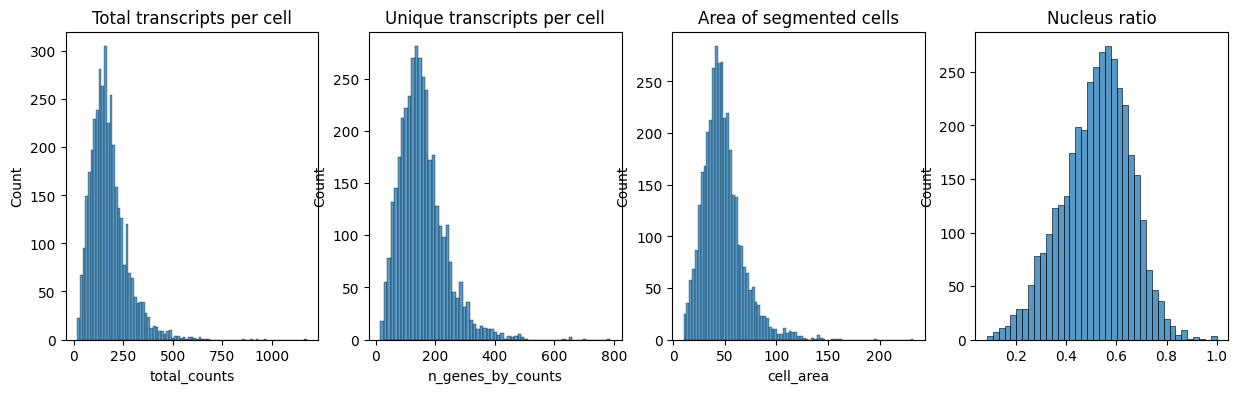

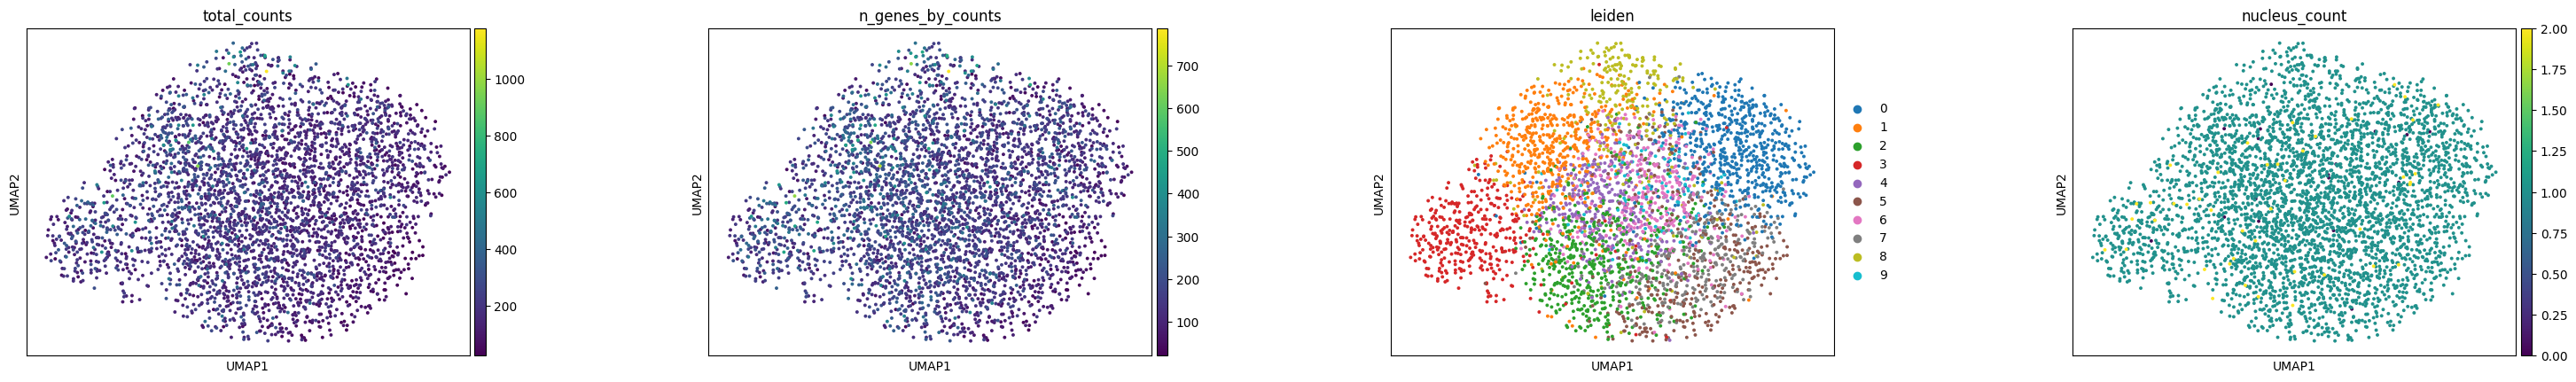

/opt/homebrew/Caskroom/miniconda/base/envs/scimilarity/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


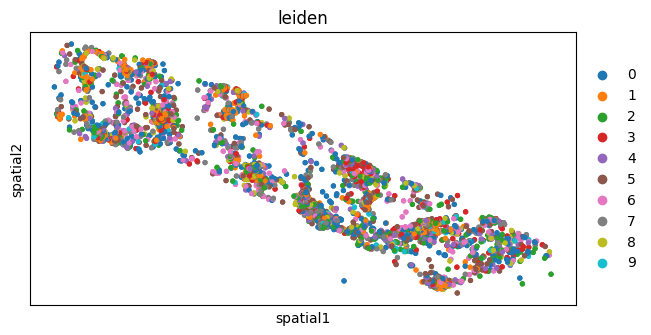

In [6]:
adata = process_xenium_adata(adata)

In [5]:
adata.shape

(29368, 5001)

In [7]:
# Instantiate the CellAnnotation object
# Set model_path to the location of the uncompressed model
model_path = "../../phaseA_process/notebook/model_v1.1"
ca = CellAnnotation(model_path=model_path)
adams = align_dataset(adata_scimilarity_sub, ca.gene_order, gene_overlap_threshold=4500)
adams = lognorm_counts(adams)
adams.obsm["X_scimilarity"] = ca.get_embeddings(adams.X)
sc.pp.neighbors(adams, use_rep="X_scimilarity")
sc.tl.umap(adams)
predictions, nn_idxs, nn_dists, nn_stats = ca.get_predictions_knn(
    adams.obsm["X_scimilarity"]
)
adams.obs["predictions_unconstrained"] = predictions.values

Get nearest neighbors finished in: 0.0021107991536458335 min


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3785/3785 [00:00<00:00, 9527.50it/s]


In [8]:
cell_type_count = adams.obs["predictions_unconstrained"].value_counts()
cell_type_count
cell_type_count = cell_type_count.index[cell_type_count >= 20]

In [9]:
adams.obs["predictions_unconstrained"].value_counts()['B cell']

19

In [10]:
cell_type_count

Index(['leukocyte', 'naive thymus-derived CD4-positive, alpha-beta T cell',
       'CD4-positive, alpha-beta T cell', 'T cell',
       'CD8-positive, alpha-beta T cell', 'regulatory T cell', 'lymphocyte',
       'CD4-positive, alpha-beta memory T cell', 'alpha-beta T cell',
       'native cell', 'classical monocyte', 'plasma cell',
       'CD16-negative, CD56-bright natural killer cell, human', 'neutrophil',
       'natural killer cell', 'pancreatic acinar cell', 'mature NK T cell'],
      dtype='object', name='predictions_unconstrained')

In [11]:
ca.safelist_celltypes(cell_type_count)
adams = ca.annotate_dataset(adams)

Get nearest neighbors finished in: 0.0030671834945678713 min


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3785/3785 [00:00<00:00, 10286.28it/s]


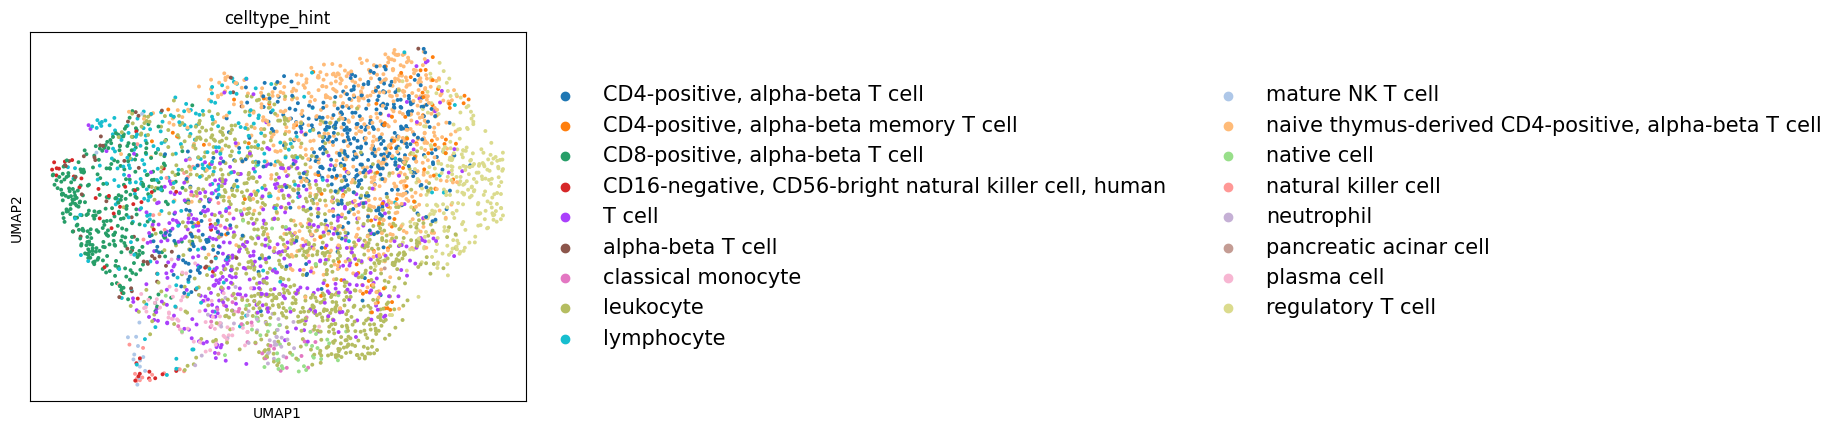

In [12]:
sc.pl.umap(adams, color="celltype_hint", legend_fontsize=15)

/opt/homebrew/Caskroom/miniconda/base/envs/scimilarity/lib/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 28231 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


categories: CD4-positive, alpha-beta T cell, CD4-positive, alpha-beta memory T cell, CD8-positive, alpha-beta T cell, etc.
var_group_labels: B-cell, Dendritic, Monocytes, etc.


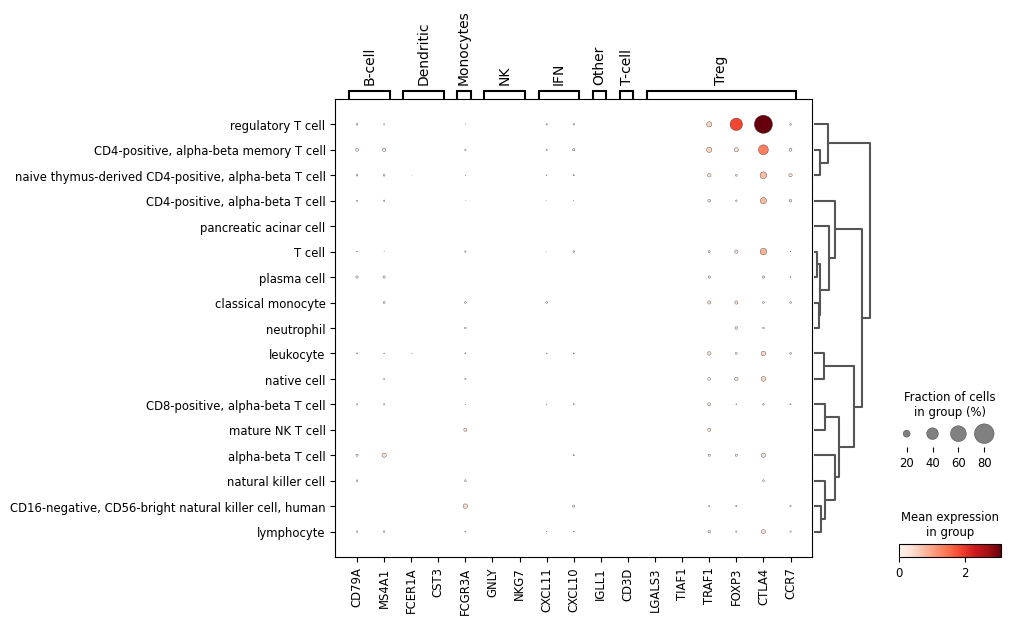

In [13]:
marker_genes_dict = {
    "B-cell": ["CD79A", "MS4A1"],
    "Dendritic": ["FCER1A", "CST3"],
    "Monocytes": ["FCGR3A"],
    "NK": ["GNLY", "NKG7"],
    "IFN": ["CXCL11", "CXCL10"],
    "Other": ["IGLL1"],
#    "Plasma": ["IGJ"],
    "T-cell": ["CD3D"],
    "Treg": ["LGALS3", "TIAF1", "TRAF1", "FOXP3", "CTLA4", "CCR7"]
}
sc.pl.dotplot(adams, marker_genes_dict, "celltype_hint", dendrogram=True)

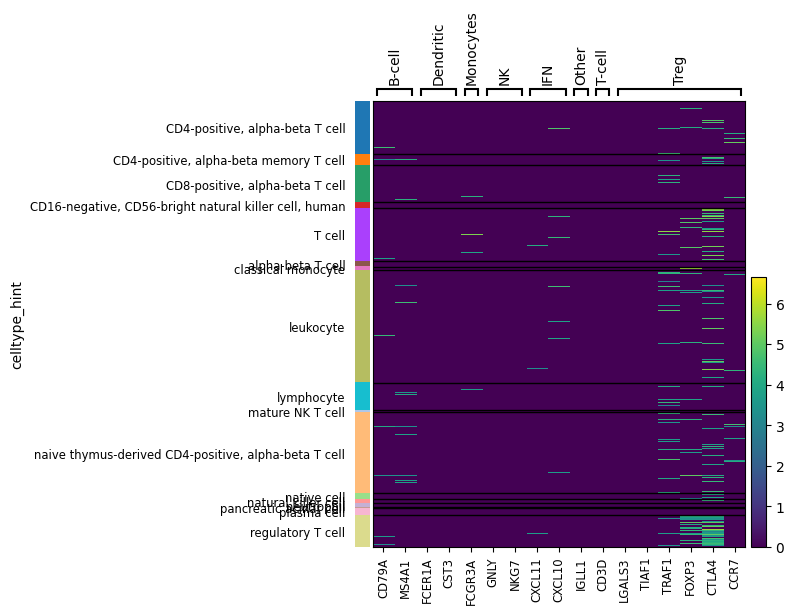

In [14]:
ax = sc.pl.heatmap(
    adams, marker_genes_dict, groupby="celltype_hint", cmap="viridis", dendrogram=False
)

In [15]:
adams.write_h5ad("kidney_T_miles.h5ad")